# Wind Farm Annual Maximum Wind Speed — Extreme Value Analysis

Fits **Gumbel**, **Fréchet**, **GEV-3P**, and **Weibull** distributions to real annual maximum
hub-height wind speed data for 8 South African wind farms (1960–2025).

**Required files (same directory as this notebook):**
- `Annual_Maxima_HubHeight.csv`
- `Test_statistics_analysis.csv`

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gumbel_r, genextreme, weibull_min
import warnings
warnings.filterwarnings('ignore')

# ── Exact colour palette ───────────────────────────────────────────────────
COL = {
    'Gumbel':  '#1f77b4',   # blue
    'Frechet': '#2ca02c',   # green
    'GEV-3P':  '#9467bd',   # purple
    'Weibull': '#ff7f0e',   # orange
}
MARKER = {
    'Gumbel':  '^',
    'Frechet': 's',
    'GEV-3P':  'D',
    'Weibull': 'o',
}
BEST_LW  = 4.0
OTHER_LW = 1.5
ALL_MODELS = ['Gumbel', 'Frechet', 'GEV-3P', 'Weibull']

print('Imports OK')

Imports OK


In [33]:
# ── Load data ─────────────────────────────────────────────────────────────
am = pd.read_csv('Annual_Maxima_HubHeight.csv').set_index('Year')

FARM_ORDER = ['De Aar','Gouda','Karusa','Noupoort',
              'Nxuba','Oyster Bay','Roggeveld','Soetwater']

ts = pd.read_csv('Test statistics analysis.csv')
# The Wind Farm column has merged cells; assign by known group-of-4 order
ts['Wind Farm'] = np.repeat(FARM_ORDER, 4)

print('Annual maxima loaded — shape:', am.shape)
print(am.describe().round(2))

Annual maxima loaded — shape: (66, 8)
       De Aar  Gouda  Karusa  Noupoort  Nxuba  Oyster Bay  Roggeveld  \
count   66.00  66.00   66.00     66.00  66.00       66.00      66.00   
mean     8.67   8.26    9.48     11.96  14.34       13.09       9.59   
std      0.86   1.33    1.50      1.10   1.10        1.30       1.52   
min      7.21   6.72    7.68     10.22  12.32       10.96       7.77   
25%      8.02   7.23    8.56     11.35  13.57       12.28       8.66   
50%      8.44   7.95    9.25     11.65  14.45       12.89       9.36   
75%      9.13   8.67    9.67     12.45  14.97       13.59       9.78   
max     10.77  12.73   15.91     16.69  17.34       19.45      16.10   

       Soetwater  
count      66.00  
mean       11.52  
std         1.46  
min         9.54  
25%        10.73  
50%        11.23  
75%        11.81  
max        17.40  


In [35]:
# ── Fitting functions (reproduce exact CSV parameter values) ───────────────

def fit_gumbel(data):
    loc, scale = gumbel_r.fit(data)
    return dict(dist=gumbel_r, p=(loc, scale))

def fit_frechet(data, shape_k):
    """Fréchet via genextreme with xi = 1/shape_k > 0  →  scipy c = -xi < 0."""
    xi = 1.0 / shape_k
    c_fit, loc_fit, scale_fit = genextreme.fit(data, f0=-xi)
    return dict(dist=genextreme, p=(c_fit, loc_fit, scale_fit))

def fit_gev3p(data):
    c, loc, scale = genextreme.fit(data)
    return dict(dist=genextreme, p=(c, loc, scale))

def fit_weibull(data):
    """2-parameter Weibull: location fixed at 0 (matches CSV shape values)."""
    c, loc, scale = weibull_min.fit(data, floc=0)
    return dict(dist=weibull_min, p=(c, loc, scale))

def cdf_(d, x): return d['dist'].cdf(x, *d['p'])
def ppf_(d, q): return d['dist'].ppf(q, *d['p'])
def pdf_(d, x): return d['dist'].pdf(x, *d['p'])

# ── Read Fréchet shape_k per farm from CSV ─────────────────────────────────
def frechet_k(farm):
    row = ts[(ts['Wind Farm'] == farm) & (ts['Distribution'] == 'Frechet')]
    return float(row['Shape (\u03be / k)'].values[0])

# ── Best model = AIC Rank 1 (lowest AIC) ─────────────────────────────────
def best_model(farm):
    row = ts[(ts['Wind Farm'] == farm) & (ts['AIC Rank'] == 1)]
    return row['Distribution'].values[0]

# ── Legend: best first, rest in ALL_MODELS order ──────────────────────────
def ordered(best):
    return [best] + [m for m in ALL_MODELS if m != best]

# Sanity-check
print('Best models:')
for f in FARM_ORDER:
    print(f'  {f:12s}: {best_model(f)}')

Best models:
  De Aar      : Gumbel
  Gouda       : GEV-3P
  Karusa      : Frechet
  Noupoort    : Frechet
  Nxuba       : GEV-3P
  Oyster Bay  : Frechet
  Roggeveld   : Frechet
  Soetwater   : Frechet


In [36]:
# ── Fit all farms ──────────────────────────────────────────────────────────
PARAMS = {}
BEST   = {}

for farm in FARM_ORDER:
    data = am[farm].values
    fk   = frechet_k(farm)
    PARAMS[farm] = {
        'Gumbel':  fit_gumbel(data),
        'Frechet': fit_frechet(data, fk),
        'GEV-3P':  fit_gev3p(data),
        'Weibull': fit_weibull(data),
    }
    BEST[farm] = best_model(farm)

# Quick parameter check against Test_statistics_analysis.csv
farm = 'De Aar'
g = PARAMS[farm]['Gumbel']
print(f"De Aar Gumbel: loc={g['p'][0]:.4f} (expect 8.2771), scale={g['p'][1]:.4f} (expect 0.6692)")
farm = 'Karusa'
f_ = PARAMS[farm]['Frechet']
print(f"Karusa Frechet: c={f_['p'][0]:.5f} (expect ~-0.09026), scale={f_['p'][2]:.4f} (expect ~0.8)")

De Aar Gumbel: loc=8.2771 (expect 8.2771), scale=0.6692 (expect 0.6692)
Karusa Frechet: c=-0.09032 (expect ~-0.09026), scale=0.7901 (expect ~0.8)


In [37]:
# ── Four-panel diagnostic plot ─────────────────────────────────────────────

def diagnostic_plots(farm):
    data   = np.sort(am[farm].values)
    params = PARAMS[farm]
    best   = BEST[farm]
    order  = ordered(best)
    n      = len(data)
    emp_p  = np.arange(1, n+1) / (n + 1)   # Weibull plotting positions

    x_lo = data.min() * 0.97
    x_hi = data.max() * 1.06
    xr   = np.linspace(x_lo, x_hi, 500)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{farm} Wind Farm', fontsize=16, fontweight='bold', y=0.98)

    # Panel 1 — Histogram + Theoretical Densities
    ax = axes[0, 0]
    ax.hist(data, bins=15, density=True, color='lightgrey',
            edgecolor='white', lw=0.5, zorder=1)
    for m in order:
        ax.plot(xr, pdf_(params[m], xr),
                color=COL[m], lw=BEST_LW if m==best else OTHER_LW,
                label=m, zorder=3)
    ax.set_xlabel('Annual Max Wind Speed (m/s)')
    ax.set_ylabel('Density')
    ax.set_title('Histogram and Theoretical Densities')
    ax.legend(fontsize=9)
    ax.set_xlim(x_lo, x_hi)

    # Panel 2 — Q-Q Plot
    ax = axes[0, 1]
    # Plot non-best models first
    for m in [model for model in ALL_MODELS if model != best]:
        th_q = ppf_(params[m], emp_p)
        ax.scatter(th_q, data, color=COL[m], marker=MARKER[m],
                   s=25, label=m, zorder=3, alpha=0.85, edgecolors='none')
    # Plot the best model last to ensure visibility
    th_q_best = ppf_(params[best], emp_p)
    ax.scatter(th_q_best, data, color=COL[best], marker=MARKER[best],
               s=35, label=best, zorder=4, alpha=1.0, edgecolors='black', linewidth=0.8)

    all_th = np.concatenate([ppf_(params[m], emp_p) for m in order])
    lo1 = min(all_th.min(), data.min()) * 0.97
    hi1 = max(all_th.max(), data.max()) * 1.03
    ax.plot([lo1, hi1], [lo1, hi1], 'k--', lw=1.2, label='1:1 line')
    ax.set_xlabel('Theoretical Quantiles (m/s)')
    ax.set_ylabel('Empirical Quantiles (m/s)')
    ax.set_title('Q-Q Plot')
    ax.legend(fontsize=9)

    # Panel 3 — P-P Plot
    ax = axes[1, 0]
    for m in order:
        th_p = cdf_(params[m], data)
        ax.scatter(emp_p, th_p, color=COL[m], marker=MARKER[m],
                   s=25, label=m, zorder=3, alpha=0.85, edgecolors='none')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='1:1 line')
    ax.set_xlabel('Empirical Probability')
    ax.set_ylabel('Theoretical Probability')
    ax.set_title('P-P Plot')
    ax.legend(fontsize=9)

    # Panel 4 — Empirical + Theoretical CDFs
    ax = axes[1, 1]
    ax.step(np.sort(data), np.arange(1, n+1)/n,
            color='black', lw=2.0, label='Empirical CDF', where='post', zorder=4)
    for m in order:
        ax.plot(xr, cdf_(params[m], xr),
                color=COL[m], lw=BEST_LW if m==best else OTHER_LW,
                label=m, zorder=3)
    ax.set_xlabel('Annual Max Wind Speed (m/s)')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title('Empirical and Theoretical CDFs')
    ax.legend(fontsize=9)
    ax.set_xlim(x_lo, x_hi)

    fig.text(0.5, 0.005,
             'Legend is arranged in order of best fit model (best model fit first)',
             ha='center', fontsize=8, style='italic', color='#444444')
    plt.tight_layout(rect=[0, 0.025, 1, 0.97])
    plt.show()

print('diagnostic_plots() ready.')

diagnostic_plots() ready.


## De Aar Wind Farm

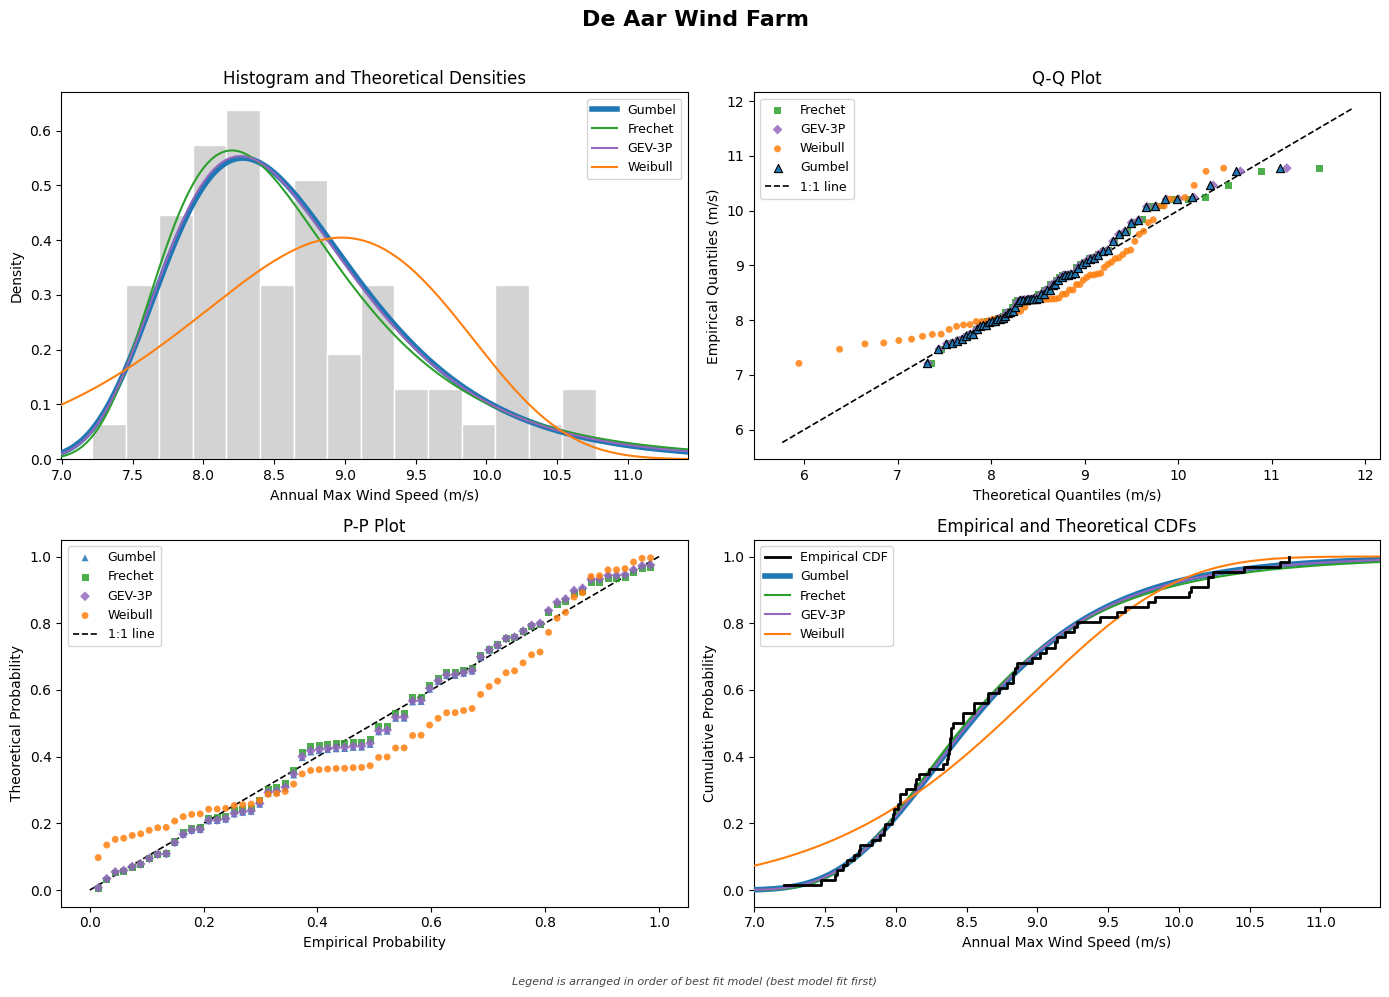

In [38]:
diagnostic_plots('De Aar')

## Gouda Wind Farm

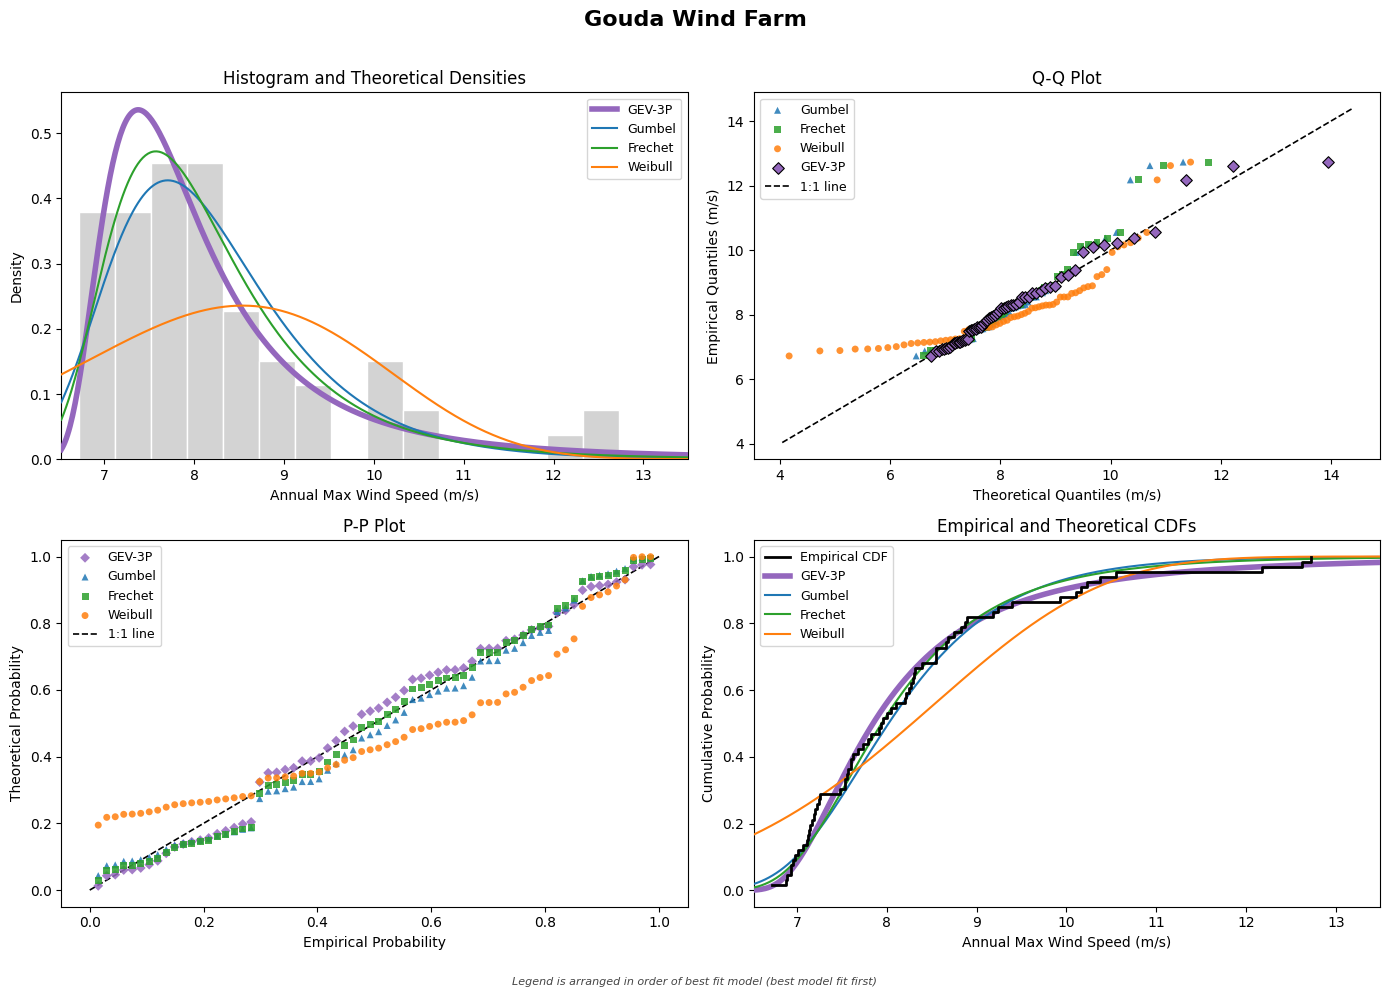

In [39]:
diagnostic_plots('Gouda')

## Karusa Wind Farm

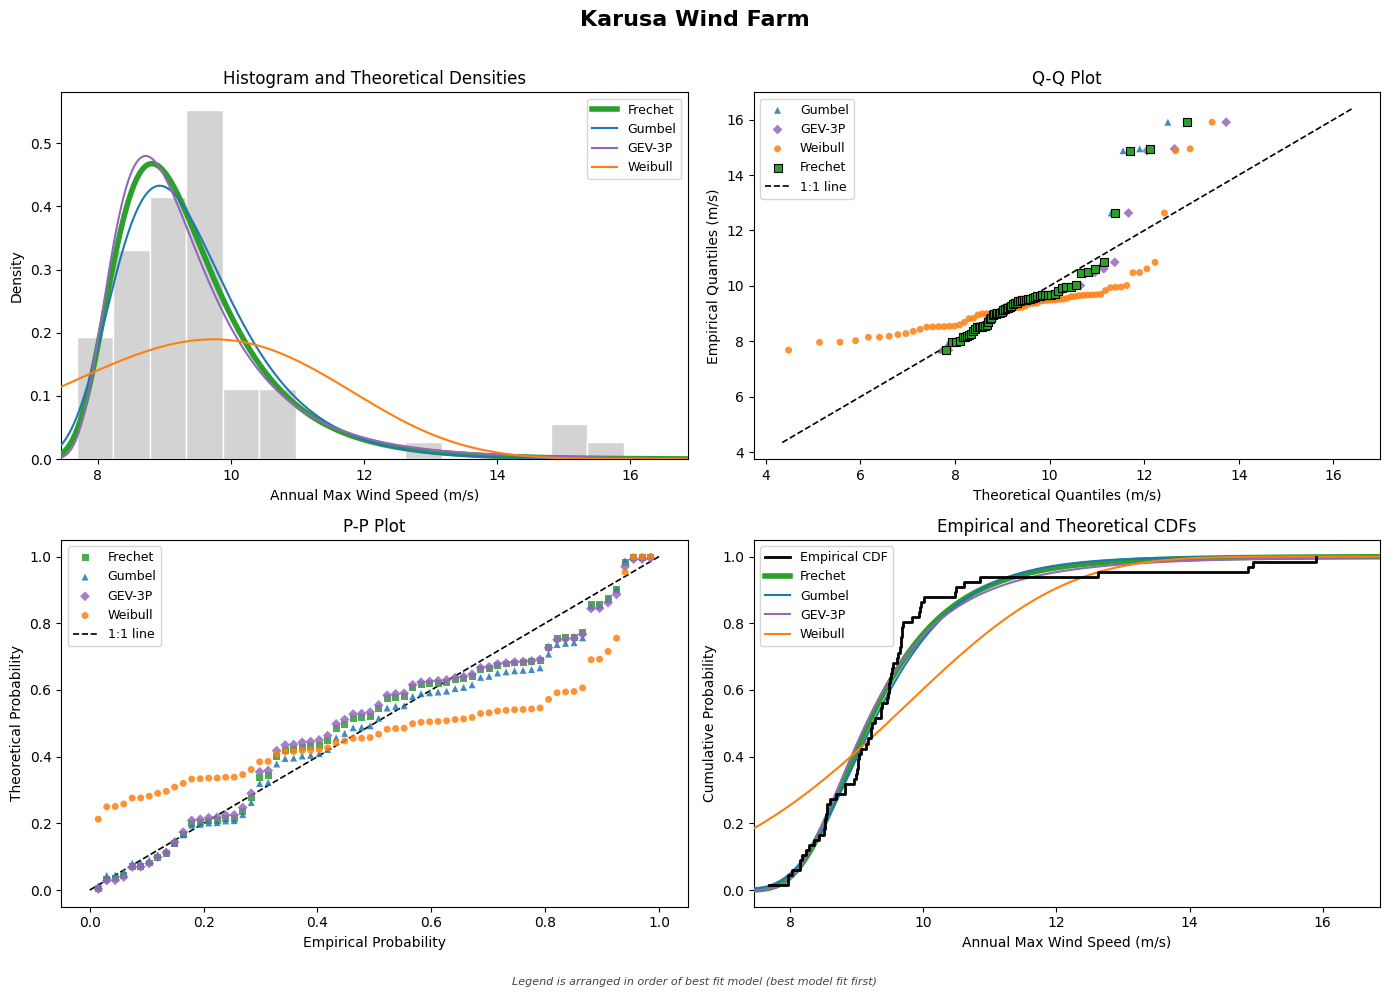

In [40]:
diagnostic_plots('Karusa')

## Noupoort Wind Farm

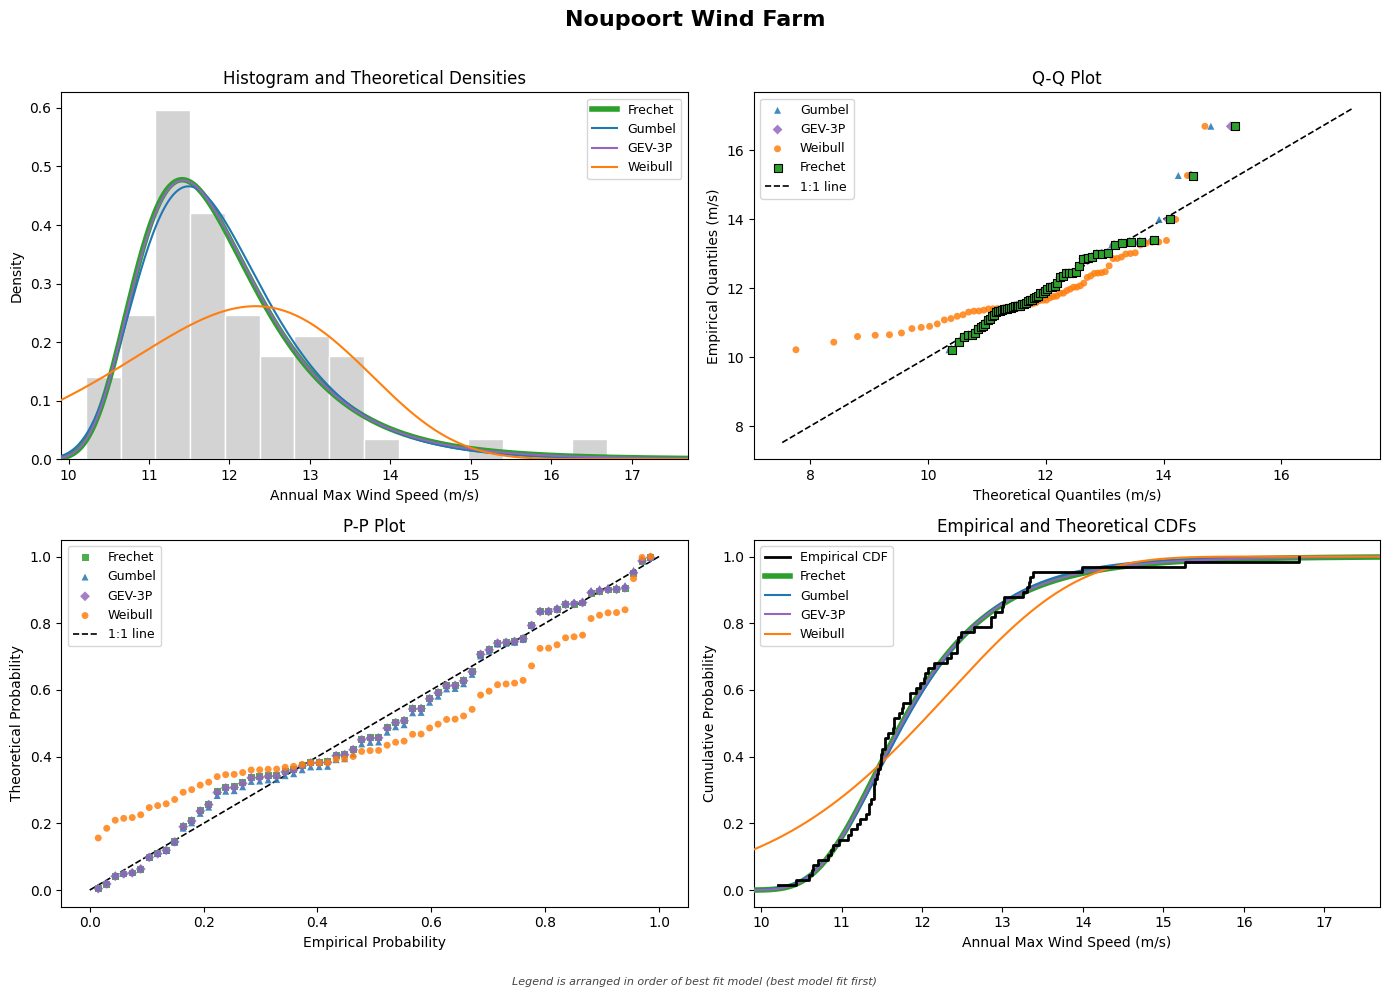

In [41]:
diagnostic_plots('Noupoort')

## Nxuba Wind Farm

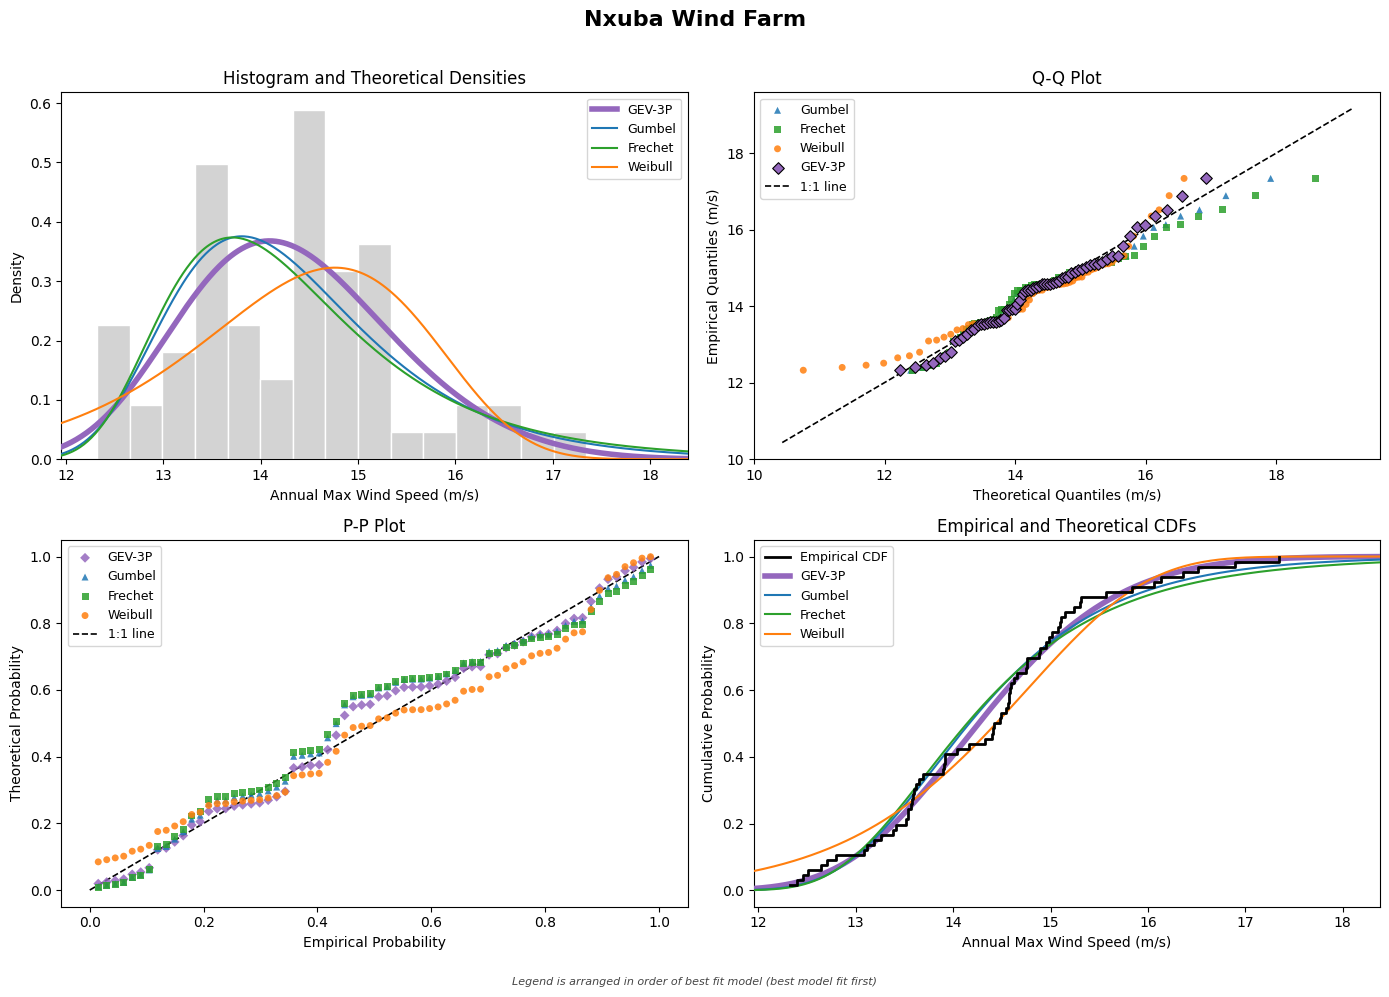

In [42]:
diagnostic_plots('Nxuba')

## Oyster Bay Wind Farm

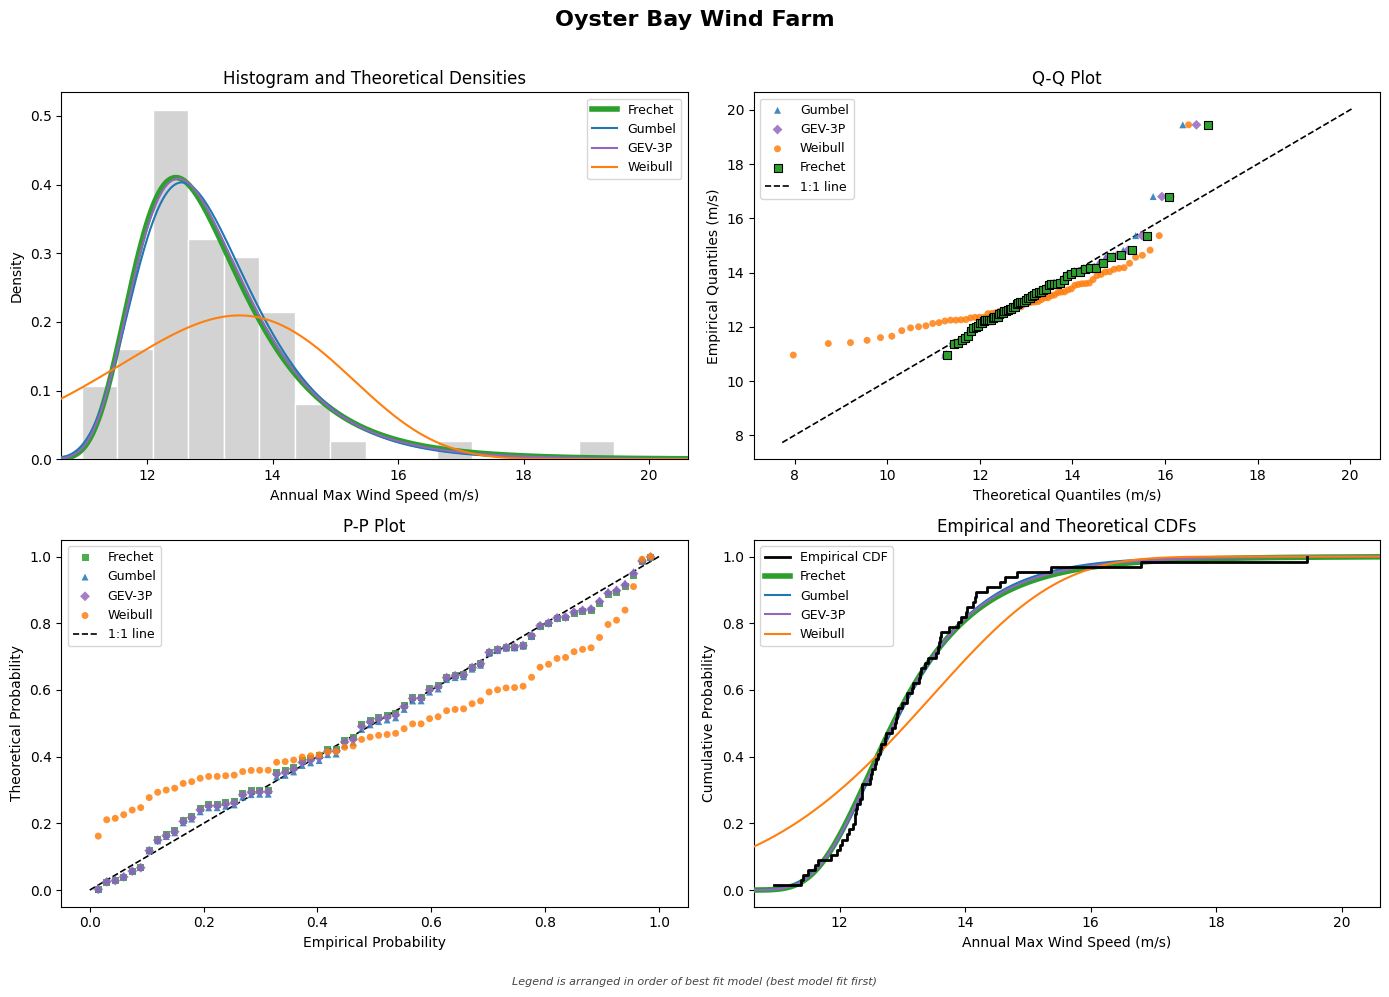

In [43]:
diagnostic_plots('Oyster Bay')

## Roggeveld Wind Farm

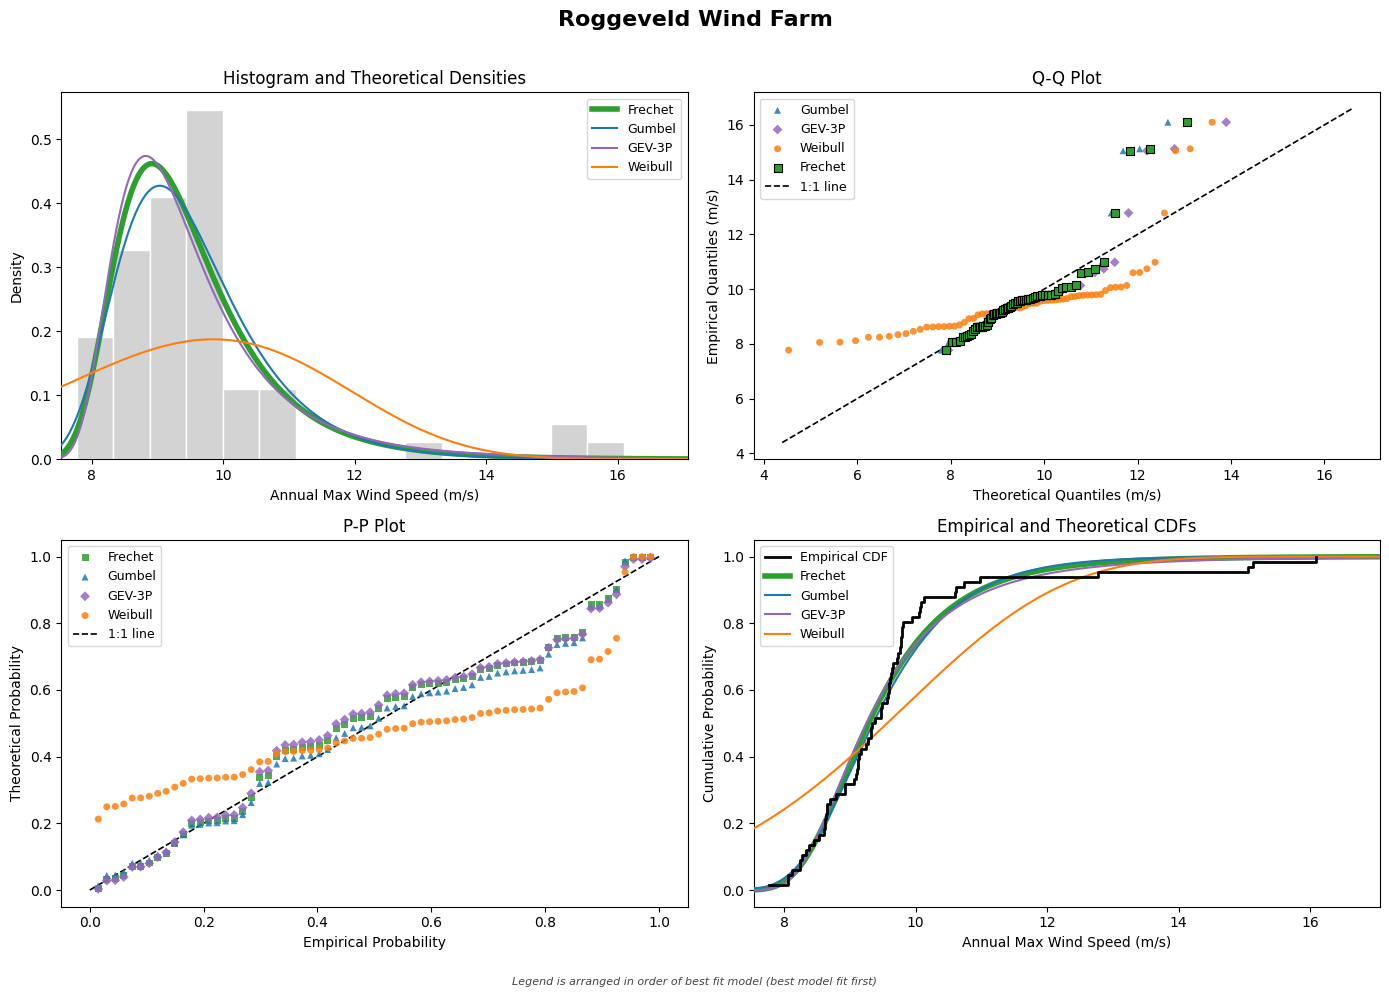

In [44]:
diagnostic_plots('Roggeveld')

## Soetwater Wind Farm

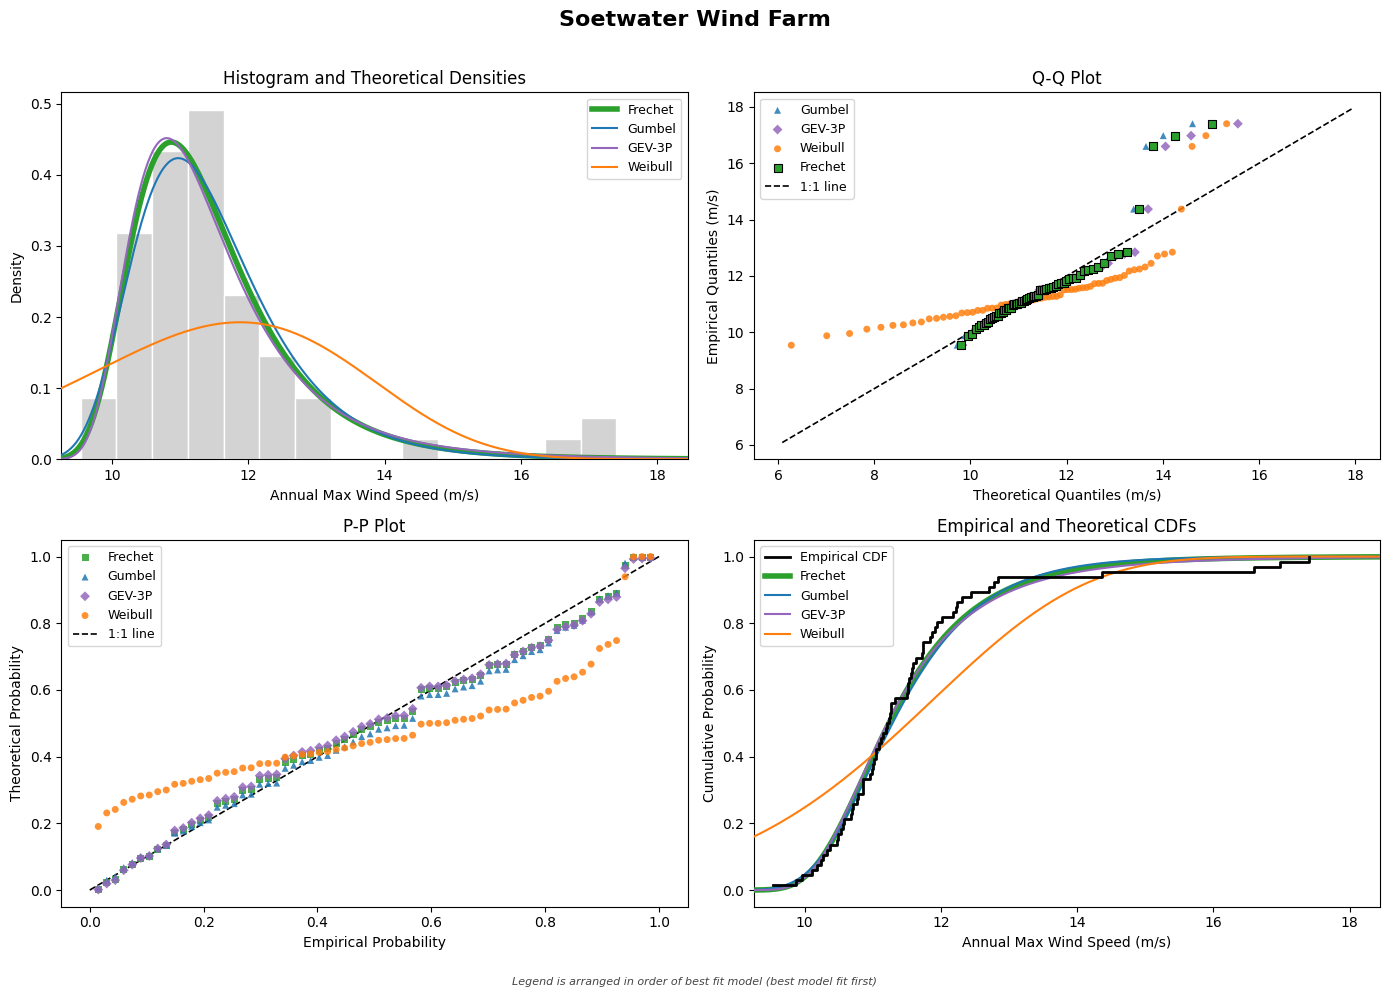

In [45]:
diagnostic_plots('Soetwater')

---
## Return Level Plots — Annual Maximum Wind Speed

Return level = wind speed expected to be exceeded once in *T* years.  
Red dashed lines = 95 % bootstrap confidence interval (500 resamples).

In [46]:
# ── Return level helpers ───────────────────────────────────────────────────

def return_level(dist_dict, T):
    return ppf_(dist_dict, 1.0 - 1.0/T)

def get_best_fit(farm):
    data = am[farm].values
    best = BEST[farm]
    fk   = frechet_k(farm)
    if   best == 'Gumbel':  return fit_gumbel(data)
    elif best == 'Frechet': return fit_frechet(data, fk)
    elif best == 'GEV-3P':  return fit_gev3p(data)
    else:                   return fit_weibull(data)

def bootstrap_ci(farm, n_boot=500, ci=0.95, seed=42):
    data  = am[farm].values
    best  = BEST[farm]
    fk    = frechet_k(farm)
    rng_b = np.random.default_rng(seed)
    T_v   = np.logspace(np.log10(1.01), np.log10(200), 200)
    boots = np.zeros((n_boot, len(T_v)))
    for i in range(n_boot):
        s = rng_b.choice(data, size=len(data), replace=True)
        try:
            if   best == 'Gumbel':  dd = fit_gumbel(s)
            elif best == 'Frechet': dd = fit_frechet(s, fk)
            elif best == 'GEV-3P':  dd = fit_gev3p(s)
            else:                   dd = fit_weibull(s)
            boots[i] = [return_level(dd, t) for t in T_v]
        except Exception:
            boots[i] = np.nan
    alpha = (1 - ci) / 2
    return T_v, np.nanpercentile(boots, alpha*100, axis=0), np.nanpercentile(boots, (1-alpha)*100, axis=0)

print('Return level helpers ready.')

Return level helpers ready.


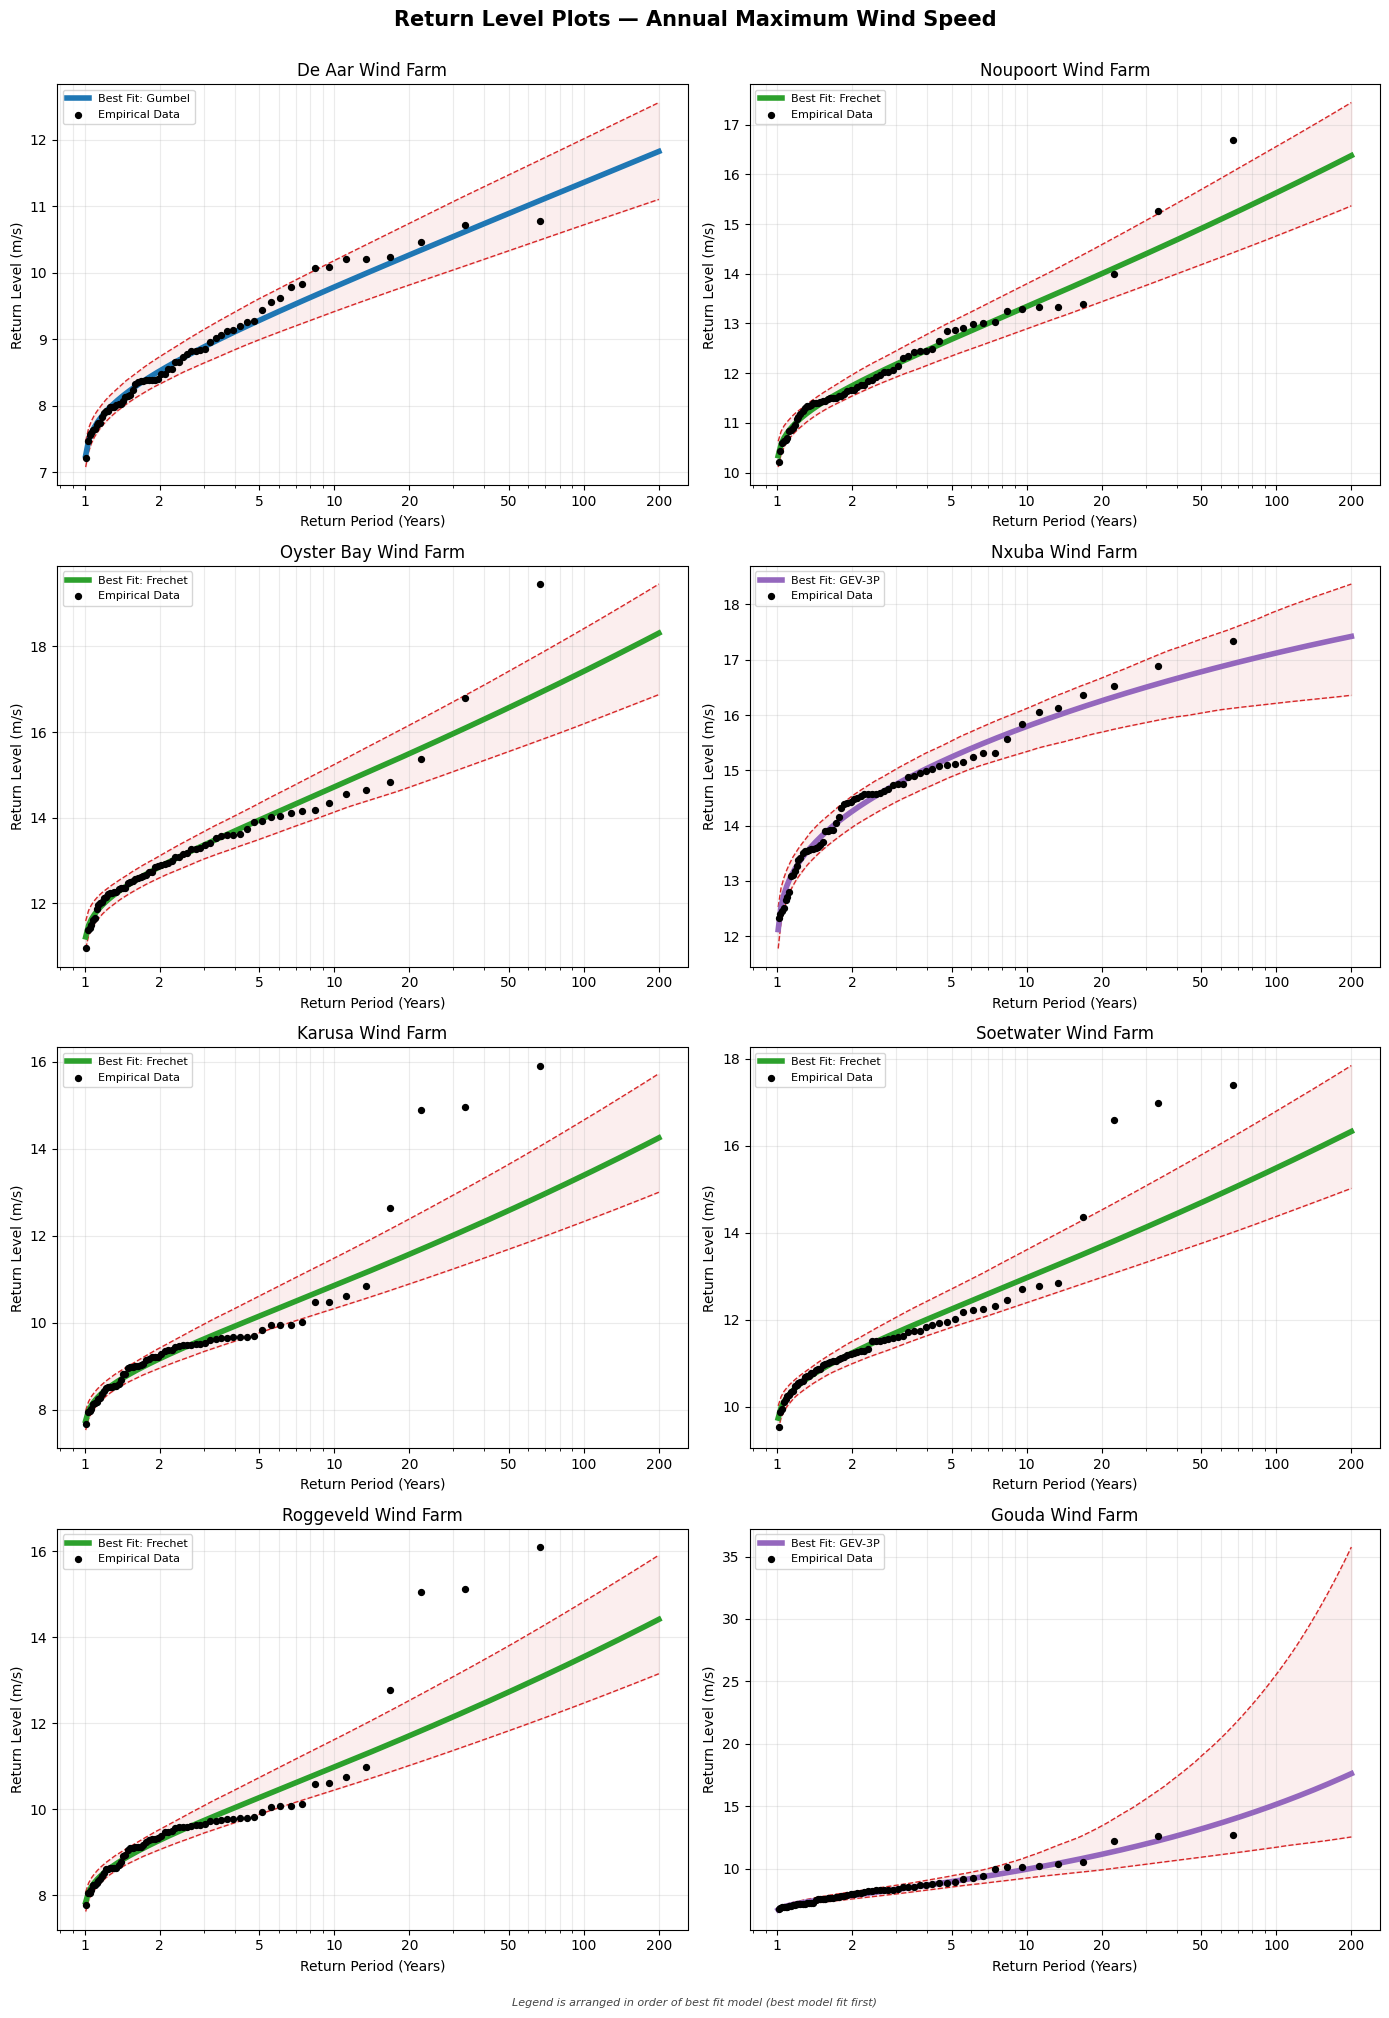

In [47]:
# ── Combined 4×2 Return Level Grid ────────────────────────────────────────
# Layout matches original image:
# Row 1: De Aar | Noupoort
# Row 2: Oyster Bay | Nxuba
# Row 3: Karusa | Soetwater
# Row 4: Roggeveld | Gouda

GRID = [('De Aar',     'Noupoort'),
        ('Oyster Bay', 'Nxuba'),
        ('Karusa',     'Soetwater'),
        ('Roggeveld',  'Gouda')]

T_plot = np.logspace(np.log10(1.01), np.log10(200), 200)

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('Return Level Plots — Annual Maximum Wind Speed',
             fontsize=15, fontweight='bold', y=0.999)

for row_i, (lf, rf) in enumerate(GRID):
    for col_i, farm in enumerate([lf, rf]):
        ax   = axes[row_i, col_i]
        data = am[farm].values
        dd   = get_best_fit(farm)
        best = BEST[farm]

        rl           = np.array([return_level(dd, t) for t in T_plot])
        T_ci, lo, hi = bootstrap_ci(farm, n_boot=500)

        n     = len(data)
        p_emp = np.arange(1, n+1) / (n+1)
        T_emp = 1.0 / (1.0 - p_emp)

        ax.plot(T_plot, rl, color=COL[best], lw=BEST_LW,
                label=f'Best Fit: {best}', zorder=3)
        ax.plot(T_ci, lo, color='#d62728', lw=1.0, ls='--', zorder=2)
        ax.plot(T_ci, hi, color='#d62728', lw=1.0, ls='--', zorder=2)
        ax.fill_between(T_ci, lo, hi, color='#d62728', alpha=0.08, zorder=1)
        ax.scatter(T_emp, np.sort(data), color='black', s=18, zorder=4,
                   label='Empirical Data')

        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200])
        ax.set_xticklabels(['1','2','5','10','20','50','100','200'])
        ax.set_xlabel('Return Period (Years)')
        ax.set_ylabel('Return Level (m/s)')
        ax.set_title(f'{farm} Wind Farm')
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, which='both', alpha=0.25)

fig.text(0.5, 0.001,
         'Legend is arranged in order of best fit model (best model fit first)',
         ha='center', fontsize=8, style='italic', color='#444444')
plt.tight_layout(rect=[0, 0.01, 1, 0.998])
plt.show()

---## Best-Fit Model Summary (AIC Rank 1)
| Wind Farm | Best Model | Max Observed (m/s) | Cut-Out Speed (m/s) | 10-Year | 20-Year | 50-Year | 100-Year |
|---|---|---|---|---|---|---|---|
| De Aar | Gumbel | 10.775 | 25 | 9.783 | 10.265 | 10.888 | 11.355 |
| Gouda | GEV-3P | 12.727 | 25 | 9.943 | 11.144 | 13.173 | 15.146 |
| Karusa | Fréchet | 15.907 | 25 | 10.888 | 11.619 | 12.640 | 13.462 |
| Noupoort | Fréchet | 16.690 | 25 | 13.337 | 14.000 | 14.906 | 15.623 |
| Nxuba | GEV-3P | 17.342 | 25 | 15.794 | 16.259 | 16.782 | 17.122 |
| Oyster Bay | Fréchet | 19.445 | 25 | 14.706 | 15.484 | 16.552 | 17.400 |
| Roggeveld | Fréchet | 16.097 | 25 | 11.018 | 11.758 | 12.790 | 13.623 |
| Soetwater | Fréchet | 17.402 | 25 | 12.984 | 13.717 | 14.729 | 15.535 |

*Return levels for Gouda and Nxuba are from the GEV-3P (AIC rank 1); the CSV's `Best model=YES` column marks Fréchet/Gumbel respectively (rank 2), which appears to be a labelling artefact in the original file.*